As a QA for the simplified noncompliance method, let's implement Ecology's method as closely as possible per Appendix F of Ahmed 2021.

In [1]:
import sys
import pathlib
import os

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray

sys.path.append('../../py_scripts')
import ssm_utils

In [2]:
case_file = '/home/benr/wqmodels/ssm/psi/projects/Ecy21_analysis/SSM_config_ecy21.yaml'
case_path = pathlib.Path(case_file)

ssm, case = ssm_utils.read_case(case_file)
shp = ssm['paths']['shapefile']

gdf = gpd.read_file(shp)
gdf = gdf.rename(columns={'region_inf':'Regions'})
regions = gdf[['node_id','Regions']].groupby(
    'Regions').count().index.to_list()

model_var='DOXG'   
processed_netcdf_dir = pathlib.Path(case_path.parent / ssm['paths']['processed_output'])/case/model_var
# Get list of run sub-directories in processed netcdf directory
dir_list = os.listdir(processed_netcdf_dir)
print(dir_list)

Inferring case name to be ecy21
['wqm_reference', 'wqm_baseline']


In [3]:
# Initialize dictionaries
MinDO_full={} # Min, daily DO over all nodes
MinDO={} # Min, daily DO over all nodes in shapefile
DO_diff_lt_0p2_days={} # Number of days where DOBelowThresh = True
DaysNonCompliant={} # Sum of days across regions
VolumeDaysNonCompliant={} # Percent of volume within region where DO<threshold
PercentVolumeDaysNonCompliant={}
AreaNonCompliant={}

for run_dir in dir_list:
    print('Getting model output for: ', run_dir)
    try: 
        run_file=processed_netcdf_dir/run_dir/'wc'/f'daily_min_{model_var}_wc.nc'
        with xarray.open_dataset(run_file) as ds:
            MinDO_full[run_dir]=ds[f'{model_var}_daily_min_wc']
            # Sub-sample nodes (from 16012 nodes to 7494)
            MinDO[run_dir]=MinDO_full[run_dir][:,:,gdf['node_id']-1]
    except FileNotFoundError:
        print(f'File Not Found: {run_file}')
    assert len(gdf) <= MinDO_full[run_dir].shape[2], "Shapefile dimensions don't match output file"
    if run_dir == dir_list[0]:
        # Get number of days and nodes
        [ndays,nlevels,nnodes]=MinDO[run_dir].shape

shape = MinDO['wqm_reference'].shape

Getting model output for:  wqm_reference
Getting model output for:  wqm_baseline


<Axes: >

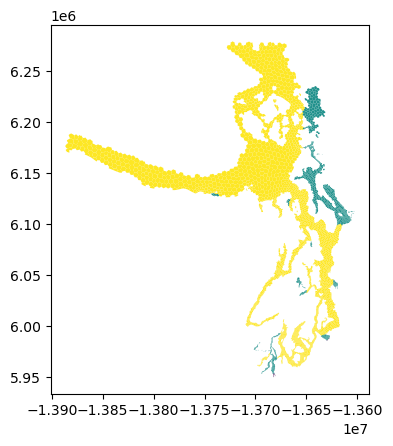

In [4]:
DO_std = np.tile(gdf.DO_std, (shape[0], shape[1], 1))
unmasked = np.tile(gdf.included_i & ~gdf.Regions.isna(), (shape[0], shape[1], 1)).astype(bool)
gdf.loc[gdf['DO_std'] != 0].plot('DO_std')

We have already done steps 1 and 3: calculate the daily minimum DO value for each grid-cell-layer for the reference and existing/scenario conditions.

## Step 2

"Compare that daily minimum DO reference condition value for each grid cell-layer with the numeric criteria in Part A and Part B"

"If the daily minimum value for the reference condition for each grid cell-layer ($DO_\mathrm{reference}$ DMin) is greater than the DO aquatic life criteria plus the human limit, then the part of the standard that is tested next is Part A (step 4)"

"If the $DO_\mathrm{reference}$ DMin is less than or equal to the DO aquatic life criteria plus the human limit then the part of the standard that is tested next is Part B"

In other words, do the part A test only if the minimum exceeds the criterion, otherwise don't do it and move on to Part B.

**note that there is some ambiguity here.** Ecology's text makes it sound like we are supposed to do Parts A and B for grid cell-layers where the reference condition exceeds the aquatic life criteria, but this does not make sense. Suppose $DO_\mathrm{reference}$ DMin is 9 mg/L, $DO_\mathrm{existing}$ DMin is 8 mg/L, and the aquatic life criteria is 7 mg/L. This would be noncompliant with a magnitude of noncompliance of -0.8 mg/L even though it exceeds the Part A standard, because it fails the Part B test.

Instead, I am interpreting Ecology's Step 2 to indicate which test is supposed to be done on any given cell. If the reference condition exceeds the aquatic use criteria by more than 0.2 mg/L, you only do Part A; otherwise you only do Part B.

np.float64(6271.571513259315)

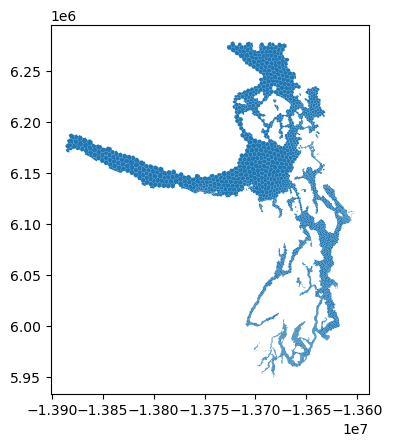

In [5]:
do_parta = (DO_std > 0) & (MinDO['wqm_reference'] > DO_std + 0.2)
# Compute the area of this region
region_do_parta = gdf.loc[pd.Series((unmasked & do_parta)[200,:,:].any(axis=0))]
region_do_parta.plot()
1e-6 * region_do_parta['Area_m2'].sum()

## Step 4

Test whether Part A of the standard is met for each grid-cell-layer:

1. Compare each existing DMin to the Part A aquatic life criteria for each location
2. If the predicted DMin is greater or equal to the criteria, then the grid-cell-layer meets Part A of the standard.
3. Otherwise it does not meet Part A of the standard.

np.float64(78.7445010138118)

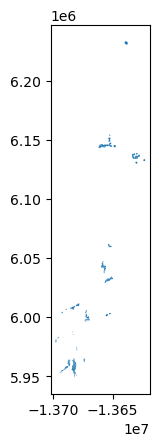

In [6]:
parta_failed = do_parta & (MinDO['wqm_baseline'] < DO_std)
# Compute the area of this region
region_parta_failed = gdf.loc[pd.Series((unmasked & parta_failed).any(axis=(0,1)))]
region_parta_failed.plot()
1e-6 * region_parta_failed.Area_m2.sum()

## Step 5

Test whether Part B of the standard is met for each grid-cell-layer:

1. The total anthropogenic depletion equals $DO_\mathrm{existing}$ DMin minus the $DO_\mathrm{reference}$ DMin. However, to account for the cumulative anthropogenic impact in the Part B portion of the standard, calculate a Part B threshold value:

In [7]:
DO_part_b = MinDO['wqm_reference'] - 0.2

2. If the predicted $DO_\mathrm{existing}$ DMin is greater or equal to $DO_\mathrm{Part B}$, then the grid-cell-layer meets Part B of the standard.
3. Otherwise it does not meet Part B of the standard.

np.float64(529.1037009851422)

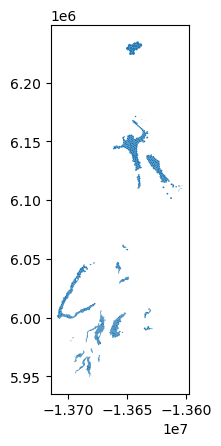

In [8]:
partb_failed = ~do_parta & (MinDO['wqm_baseline'] < DO_part_b)
# Compute the area of this region
region_partb_failed = gdf.loc[pd.Series((unmasked & partb_failed).any(axis=(0,1)))]
region_partb_failed.plot()
1e-6 * region_partb_failed.Area_m2.sum()

## Step 6

Compile the magnitudes of predicted DO noncompliances for all corresponding grid-cell-layers where either Part A or Part B of the standard is predicted not to be met, and compute the largest of the daily noncompliance magnitude for each grid cell.

Here I also add the masking filter.

In [9]:
noncompliant = (parta_failed | partb_failed) & unmasked

parta_magnitude = np.where(unmasked & parta_failed, MinDO['wqm_baseline'] - DO_std, 0)
partb_magnitude = np.where(unmasked & partb_failed, MinDO['wqm_baseline'] - DO_part_b, 0)
magnitude = np.minimum(parta_magnitude, partb_magnitude).min(axis=1)
1e-6 * gdf.Area_m2.loc[magnitude.min(axis=0) < 0].sum()

np.float64(529.9814583181251)

## Step 7

Round the magnitude of predicted noncompliances to the nearest tenth.

<Axes: >

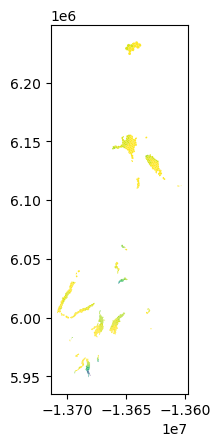

In [10]:
magnitude_rnd = magnitude.round(decimals=1)
gdf['magnitude_noncompl'] = magnitude_rnd.min(axis=0)
gdf.loc[gdf['magnitude_noncompl'] < 0].plot('magnitude_noncompl')

In [11]:
area_noncompliant_allregions = 1e-6 * gdf.Area_m2.loc[magnitude_rnd.min(axis=0) < 0].sum()
area_noncompliant_allregions

np.float64(350.1236451975358)

Let's do a total days check for good measure.

In [12]:
total_days_noncompliant = len(magnitude_rnd.min(axis=1).nonzero()[0])
total_days_noncompliant

229